In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules, 
    volcano_plot_region_within_group
)
import scanpy as sc
import numpy as np

import scanpy as sc
import matplotlib.pyplot as plt

pig_genes  = [
    "Apoe", "Arpc1b", "Axl", "B2m", "C1qa", "C1qb", "C1qc", "C4b",
    "Cd63", "Cd9", "Clu", "Csf1r", "Cst3", "Ctsa", "Ctsb", "Ctsd",
    "Ctsh", "Ctsl", "Ctss", "Ctsz", "Cx3cr1", "Cyba", "Fcer1g", "Fcgr3",
    "Fcrls", "Gfap", "Gns", "Grn", "Gusb", "H2-D1", "H2-K1", "Hexa",
    "Hexb", "Igfbp5", "Itgb5", "Itm2b", "Laptm5", "Lgals3bp", "Lgmn", "Ly86",
    "Lyz2", "Man2b1", "Mpeg1", "Npc2", "Olfml3", "Plek", "Prdx6",
    "S100a6", "Serpina3n", "Trem2", "Tyrobp", "Vsir"
]
olig_genes = [
    "Plp1", "Mbp", "Mobp", "Cnp", "Cldn11", "Mal", "Apod", "Trf", "Fth1", "Plekhb1", "Ppp1r14a", "Ttyh2", "Fa2h", "Aspa"
]
modules = {
    "PIG": pig_genes,
    "OLIG": olig_genes
}




In [2]:
ad = sc.read_h5ad('../data/ST_BRICHOS_region.h5ad')

In [3]:
pig_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2",
    "Cst7", "Fcer1g", "Axl", "Lpl", "Csf1", "Csf1r", "Cst3", "Ctsb",
    "Gpnmb", "Hexb", "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]

In [4]:
sc.tl.score_genes(ad, gene_list=pig_genes, score_name="PIG_score")

In [5]:
ad_sub = ad[ad.obs.treatment == 'PBS']

In [6]:
region_scores = ad_sub.obs.groupby("region_annotation")["PIG_score"].mean().sort_values(ascending=False)

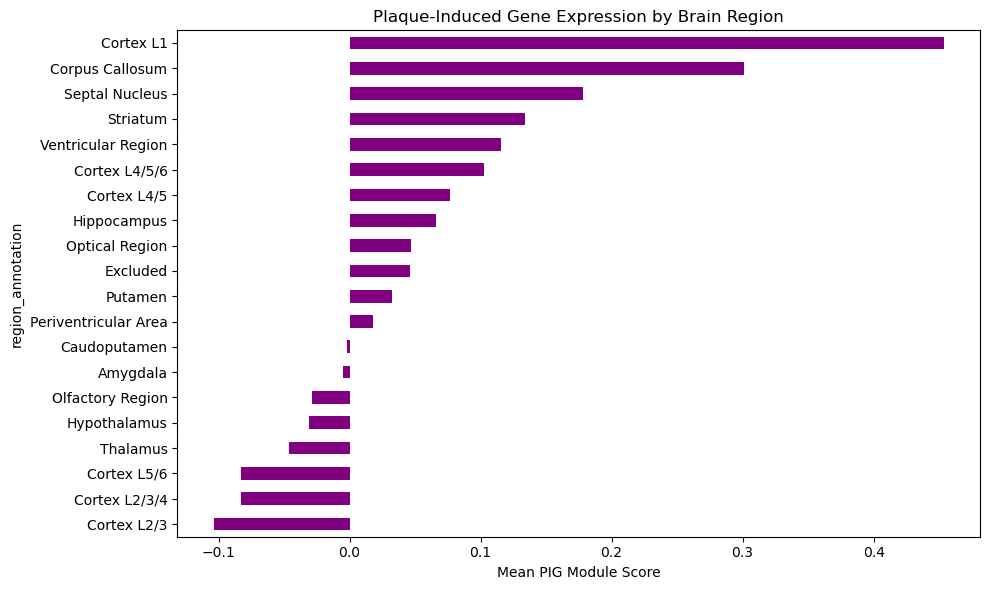

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
region_scores.plot(kind="barh", color="purple")
plt.xlabel("Mean PIG Module Score")
plt.title("Plaque-Induced Gene Expression by Brain Region")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
group = "PBS"  # or "PBS"
ad_sub = ad[ad.obs["treatment"] == group].copy()

In [9]:
sc.tl.rank_genes_groups(
    ad_sub,
    groupby="region_annotation",
    method="t-test_overestim_var"
)

In [10]:
region_de_df = sc.get.rank_genes_groups_df(ad_sub, group=None)  # returns all groups

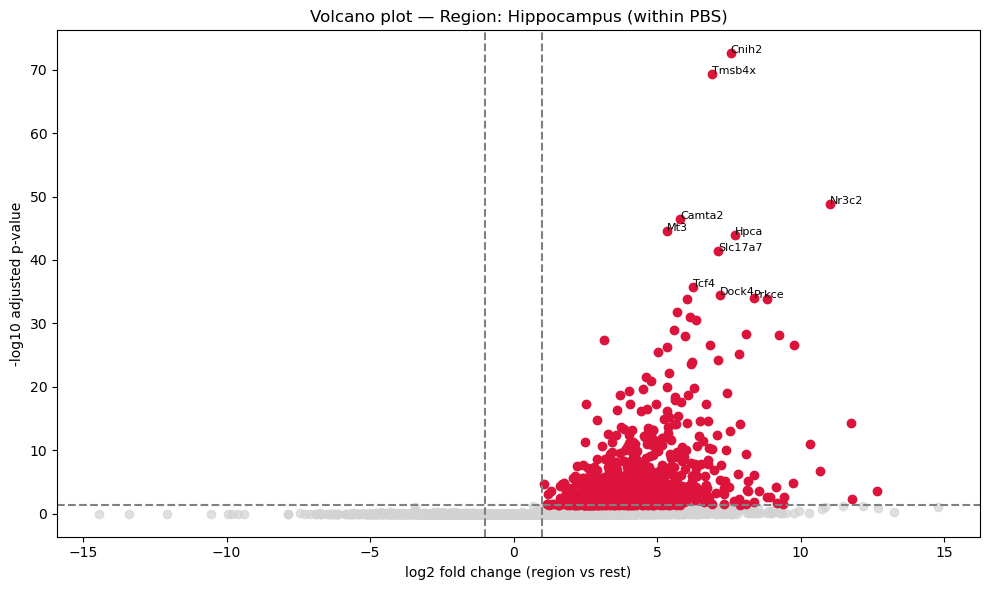

In [11]:
volcano_plot_region_within_group(ad_sub, region="Hippocampus")

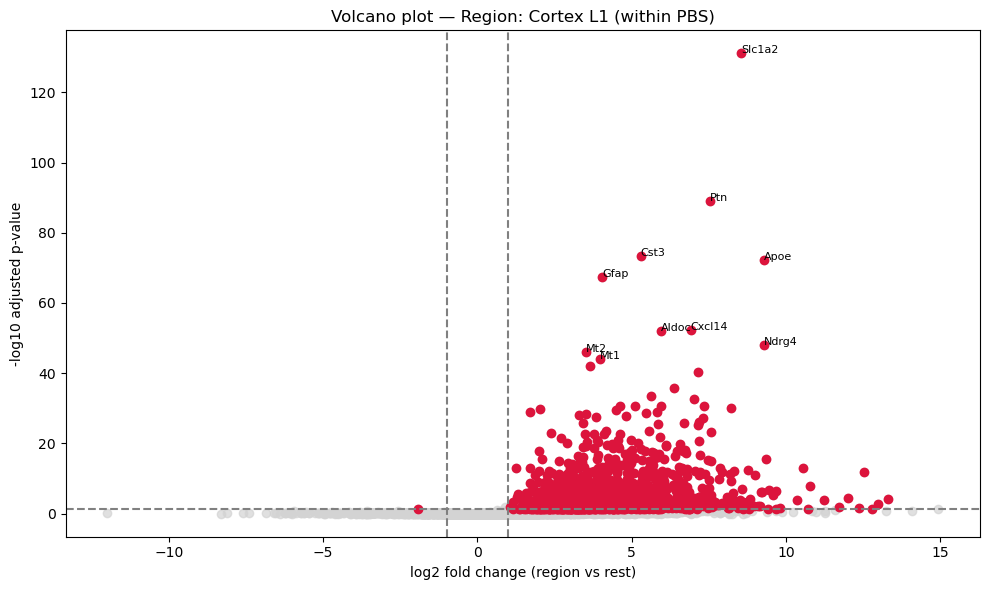

In [12]:
volcano_plot_region_within_group(ad_sub, region="Cortex L1")

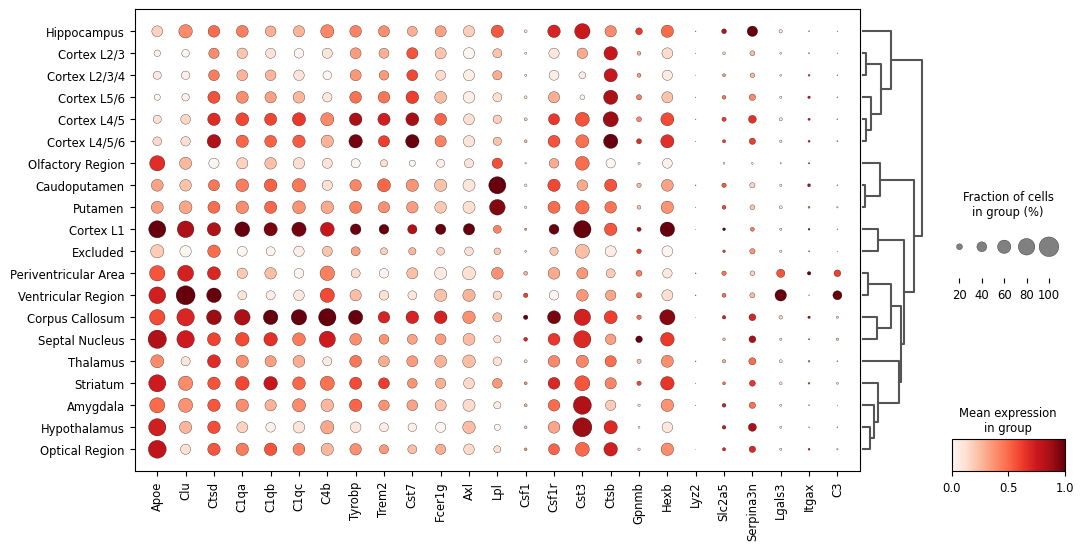

In [13]:
# Filter PBS samples with region annotations
ad_pbs = ad[(ad.obs["treatment"] == "PBS") & (ad.obs["region_annotation"].notna())].copy()

# Plot dotplot of PIG genes across regions
sc.pl.dotplot(
    ad_pbs,
    var_names=pig_genes,
    groupby="region_annotation",
    standard_scale='var',  # optional: normalize each gene across groups
    dendrogram=True,
    figsize=(12, 6),
    show=True
)

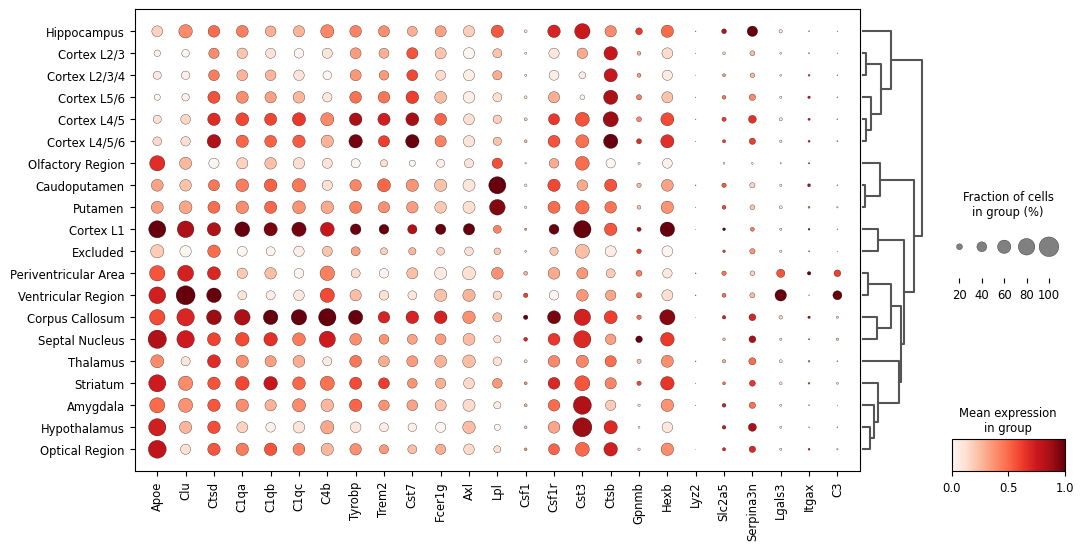

In [14]:
# Filter PBS samples with region annotations
ad_pbs = ad[(ad.obs["treatment"] == "PBS") & (ad.obs["region_annotation"].notna())].copy()

# Plot dotplot of PIG genes across regions
sc.pl.dotplot(
    ad_pbs,
    var_names=pig_genes,
    groupby="region_annotation",
    standard_scale='var',  # optional: normalize each gene across groups
    dendrogram=True,
    figsize=(12, 6),
    show=True
)

✅ Scored PIG module with 52 genes
✅ Scored OLIG module with 14 genes


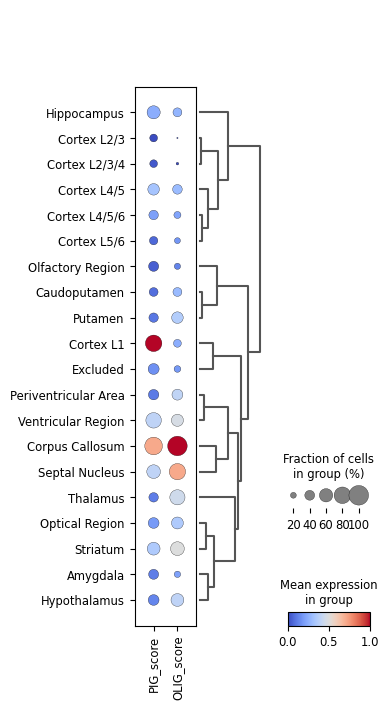

In [15]:
score_and_plot_modules(ad, modules, groupby="region_annotation")

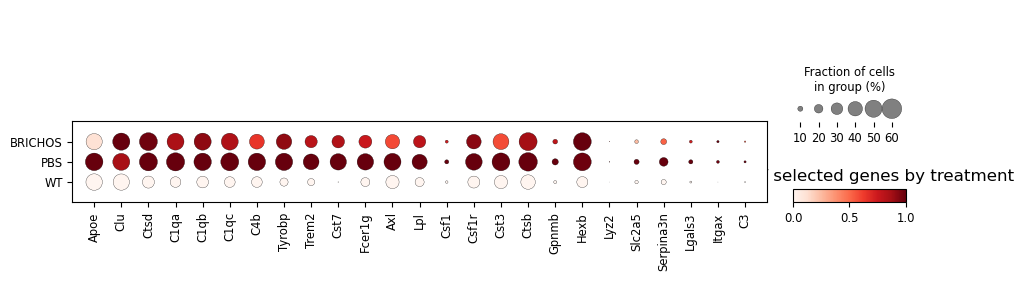

In [19]:
plaque_induced_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2",
    "Cst7", "Fcer1g", "Axl", "Lpl", "Csf1", "Csf1r", "Cst3",
    "Ctsb", "Gpnmb", "Hexb", "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]

plot_dotplot_by_treatment(ad, genes=plaque_induced_genes)

✅ Scored PIG module with 25 genes
✅ Scored OLIG module with 14 genes


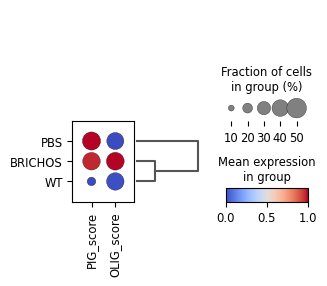

In [16]:
modules = {
    "PIG": pig_genes,
    "OLIG": olig_genes
}
score_and_plot_modules(ad, modules, groupby="treatment")

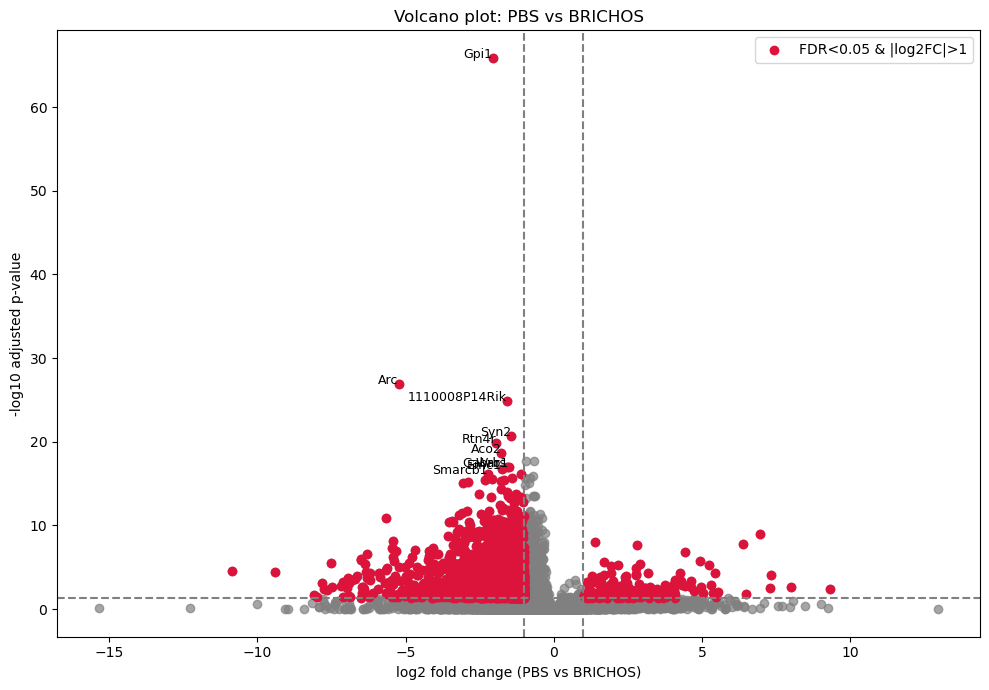

In [17]:
ad_sub = ad[ad.obs.region_annotation == 'Cortex L1']
volcano_plot_br(ad_sub, groupby='treatment',
    group1='PBS',
    group2='BRICHOS')

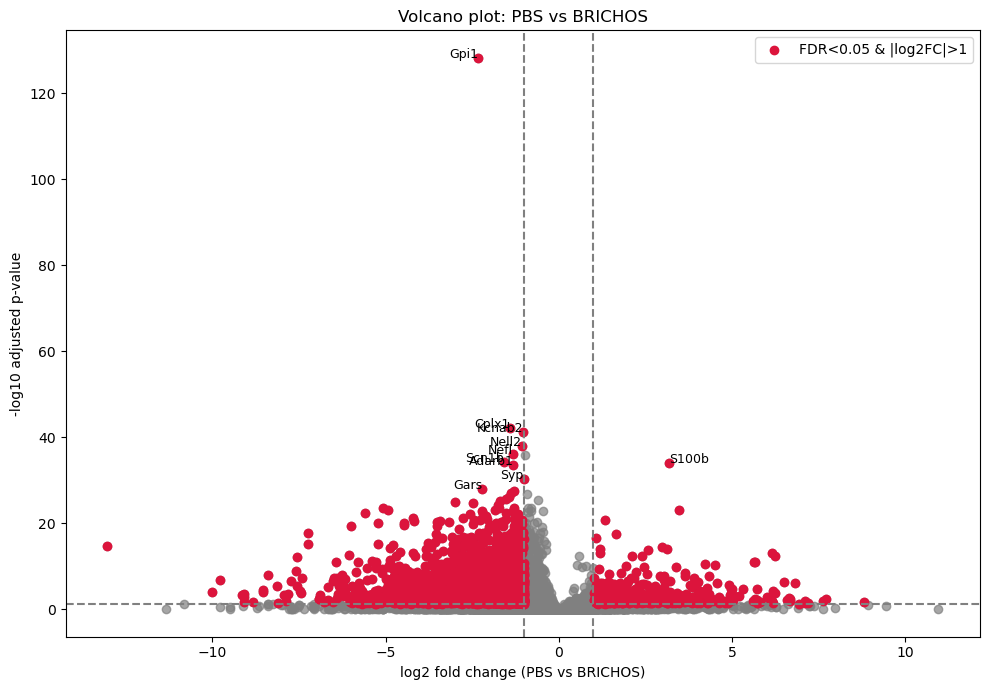

In [18]:
ad_sub = ad[ad.obs.region_annotation == 'Corpus Callosum']
volcano_plot_br(ad_sub, groupby='treatment',
    group1='PBS',
    group2='BRICHOS')

In [29]:
import pandas as pd

# group mean PIG scores
region_summary = (
    ad.obs.groupby(["region_annotation", "treatment"])["PIG_score"]
    .mean()
    .reset_index()
)

print(region_summary.head())

  region_annotation treatment  PIG_score
0          Amygdala   BRICHOS        NaN
1          Amygdala       PBS  -0.005244
2          Amygdala        WT        NaN
3      Caudoputamen   BRICHOS        NaN
4      Caudoputamen       PBS  -0.001999


In [30]:
pivot_tbl = region_summary.pivot(index="region_annotation", columns="treatment", values="PIG_score")
pivot_tbl["PBS_vs_WT"] = pivot_tbl["PBS"] - pivot_tbl["WT"]
pivot_tbl["BRICHOS_vs_PBS"] = pivot_tbl["BRICHOS"] - pivot_tbl["PBS"]
pivot_tbl = pivot_tbl.sort_values("PBS_vs_WT", ascending=False)
print(pivot_tbl)

treatment              BRICHOS       PBS  WT  PBS_vs_WT  BRICHOS_vs_PBS
region_annotation                                                      
Amygdala                   NaN -0.005244 NaN        NaN             NaN
Caudoputamen               NaN -0.001999 NaN        NaN             NaN
Corpus Callosum       0.308306  0.301019 NaN        NaN        0.007288
Cortex L1             0.525925  0.453261 NaN        NaN        0.072663
Cortex L2/3          -0.104649 -0.103617 NaN        NaN       -0.001032
Cortex L2/3/4              NaN -0.082934 NaN        NaN             NaN
Cortex L4/5                NaN  0.077018 NaN        NaN             NaN
Cortex L4/5/6        -0.076199  0.102501 NaN        NaN       -0.178700
Cortex L5/6                NaN -0.082593 NaN        NaN             NaN
Excluded             -0.007414  0.046282 NaN        NaN       -0.053696
Hippocampus                NaN  0.066064 NaN        NaN             NaN
Hypothalamus               NaN -0.030962 NaN        NaN         

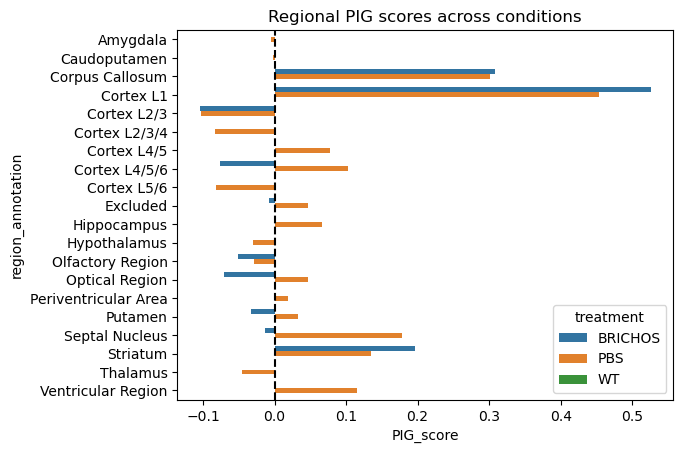

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=region_summary,
    x="PIG_score", y="region_annotation", hue="treatment",
    order=pivot_tbl.index
)
plt.axvline(0, color="k", linestyle="--")
plt.title("Regional PIG scores across conditions")
plt.show()